In [120]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
import torch.optim as optim
import cv2
import json
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.model_selection import GroupKFold, train_test_split, GroupShuffleSplit
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [122]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

In [123]:
dataset = os.path.join('/content/drive/MyDrive/DMSA')
metadata = os.path.join('/content/drive/MyDrive/Dataset/dataset.csv')

In [124]:
with open("/content/drive/MyDrive/Dataset/dmsa.json", "r") as f:
    annotations = json.load(f)

In [125]:
def create_kidney_mask(image_shape, regions):
    mask = np.zeros(image_shape[:2], dtype=np.uint8)

    for region in regions.values():
        xs = region["shape_attributes"]["all_points_x"]
        ys = region["shape_attributes"]["all_points_y"]
        polygon = np.array(list(zip(xs, ys)), dtype=np.int32)
        cv2.fillPoly(mask, [polygon], 255)

    return mask

In [126]:
def mask_and_crop(image, mask, padding=10):
    masked = cv2.bitwise_and(image, image, mask=mask)

    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return image  # fallback if mask fails

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    # add small padding
    h, w = image.shape[:2]
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(w, x_max + padding)
    y_max = min(h, y_max + padding)

    cropped = masked[y_min:y_max, x_min:x_max]
    return cropped

In [127]:
df = pd.read_csv(metadata)
df['link'] = df['link'].str.replace("\\", "/", regex=False)
df['scar'] = (df['scar'] == 'YES').astype(int)

In [128]:
groups = df['patient'].values

gss = GroupShuffleSplit(n_splits = 1, test_size = 0.15, random_state = 42)

train_val_idx, test_idx = next(gss.split(df, groups=groups))

groups_train_val = groups[train_val_idx]
gss = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)

train_idx, val_idx = next(
    gss.split(
        df.iloc[train_val_idx],
        groups = groups_train_val
    )
)

train_df = df.iloc[train_val_idx].iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[train_val_idx].iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

In [129]:
# train_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5], std=[0.5])
# ])

# val_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5], std=[0.5])
# ])


from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # grayscale
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [130]:
# def crop_sides(img, top=0.12, bottom=0.05, left=0.05, right=0.12):
#     _, h, w = img.shape
#     t = int(h * top)
#     b = h - int(h * bottom)
#     l = int(w * left)
#     r = w - int(w * right)
#     return img[:, t:b, l:r]

In [131]:
class DMSADataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'link']
        label = self.df.loc[idx, 'scar']

        img_path = os.path.join(dataset, img_path)
        filename = os.path.basename(img_path)

        image = Image.open(img_path).convert('L')
        image = np.array(image)

        ann = annotations.get(filename, None)

        if ann is not None:
            mask = create_kidney_mask(image.shape, ann["regions"])
            image = mask_and_crop(image, mask)

        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        # image = crop_sides(image)

        return image, torch.tensor(label, dtype=torch.float)

In [132]:
# pos_weight = torch.tensor([2060 / 234])
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [133]:
train_dataset = DMSADataset(train_df, transform=train_transforms)
val_dataset   = DMSADataset(val_df, transform=val_transforms)
test_dataset  = DMSADataset(test_df, transform=val_transforms)

In [134]:
labels = train_df['scar'].values  # 0/1
class_counts = np.bincount(labels)
class_weights = 1. / class_counts
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [135]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [136]:
# model = models.resnet18(pretrained=True)

# model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# model.fc = nn.Linear(model.fc.in_features, 1)

In [137]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

old_conv = model.conv1

model.conv1 = nn.Conv2d(
    1,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# Average RGB weights → grayscale
model.conv1.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 1)
)

# # grayscale
# model.fc = nn.Linear(model.fc.in_features, 1)  # binary output

In [138]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [139]:
num_epochs = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [140]:
# Class imbalance
# pos_weight = torch.tensor([2060 / 234])
# pos_weight = torch.tensor([3.0]).to(device)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
criterion = nn.BCEWithLogitsLoss()

In [141]:
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [142]:
# Scheduler for adaptive LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [143]:
# from sklearn.metrics import roc_auc_score

# best_val_auc = 0.0

# for epoch in range(num_epochs):

#     model.train()
#     train_loss = 0.0
#     all_labels = []
#     all_preds = []

#     for images, labels in train_loader:
#         images = images.to(device)
#         labels = labels.float().to(device)

#         optimizer.zero_grad()
#         outputs = model(images).squeeze()
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item() * images.size(0)
#         all_labels.extend(labels.detach().cpu().numpy())
#         all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())

#     train_auc = roc_auc_score(all_labels, all_preds)
#     train_loss /= len(train_loader.dataset)

#     model.eval()
#     val_loss = 0.0
#     val_labels = []
#     val_preds = []

#     with torch.no_grad():
#         for images, labels in val_loader:
#             images = images.to(device)
#             labels = labels.float().to(device)

#             outputs = model(images).squeeze()
#             loss = criterion(outputs, labels)

#             val_loss += loss.item() * images.size(0)
#             val_labels.extend(labels.detach().cpu().numpy())
#             val_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())

#     val_auc = roc_auc_score(val_labels, val_preds)
#     val_loss /= len(val_loader.dataset)

#     print(f"Epoch [{epoch+1}/{num_epochs}]  "
#           f"Train Loss: {train_loss:.4f}  Train AUC: {train_auc:.4f}  "
#           f"Val Loss: {val_loss:.4f}  Val AUC: {val_auc:.4f}")


#     if val_auc > best_val_auc:
#         best_val_auc = val_auc
#         torch.save(model.state_dict(), "best_model.pth")


In [144]:
from sklearn.metrics import roc_auc_score, confusion_matrix, recall_score

from tqdm import tqdm

patience = 5
num_epochs = 20
best_val_auc = 0.0
epochs_no_improve = 0

train_aucs, val_aucs = [], []

for epoch in range(num_epochs):
    # ----- TRAIN -----
    model.train()
    all_labels, all_preds = [], []
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())

    train_auc = roc_auc_score(all_labels, all_preds)
    train_aucs.append(train_auc)
    train_loss /= len(train_loader.dataset)

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0.0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_labels.extend(labels.cpu().numpy())
            val_preds.extend(torch.sigmoid(outputs).cpu().numpy())

    val_auc = roc_auc_score(val_labels, val_preds)
    val_aucs.append(val_auc)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train AUC: {train_auc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val AUC: {val_auc:.4f}")

    # LR Scheduler step
    scheduler.step(val_auc)

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs!")
        break

Epoch 1 - Validation: 100%|██████████| 19/19 [00:33<00:00,  1.75s/it]


Epoch [1/20]  Train Loss: 0.6054  Train AUC: 0.7401  Val Loss: 0.7302  Val AUC: 0.7495


Epoch 2 - Validation: 100%|██████████| 19/19 [00:32<00:00,  1.72s/it]


Epoch [2/20]  Train Loss: 0.5488  Train AUC: 0.8013  Val Loss: 0.5276  Val AUC: 0.7402


Epoch 3 - Validation: 100%|██████████| 19/19 [00:32<00:00,  1.72s/it]


Epoch [3/20]  Train Loss: 0.5150  Train AUC: 0.8263  Val Loss: 0.5841  Val AUC: 0.7404


Epoch 4 - Validation: 100%|██████████| 19/19 [00:34<00:00,  1.82s/it]


Epoch [4/20]  Train Loss: 0.4454  Train AUC: 0.8743  Val Loss: 0.5864  Val AUC: 0.7537


Epoch 5 - Validation: 100%|██████████| 19/19 [00:31<00:00,  1.67s/it]


Epoch [5/20]  Train Loss: 0.4791  Train AUC: 0.8534  Val Loss: 0.4150  Val AUC: 0.7260


Epoch 6 - Validation: 100%|██████████| 19/19 [00:32<00:00,  1.70s/it]


Epoch [6/20]  Train Loss: 0.4212  Train AUC: 0.8875  Val Loss: 0.5725  Val AUC: 0.7260


Epoch 7 - Validation: 100%|██████████| 19/19 [00:31<00:00,  1.66s/it]


Epoch [7/20]  Train Loss: 0.3937  Train AUC: 0.9023  Val Loss: 0.4872  Val AUC: 0.7335


Epoch 8 - Validation: 100%|██████████| 19/19 [00:30<00:00,  1.59s/it]


Epoch [8/20]  Train Loss: 0.3729  Train AUC: 0.9129  Val Loss: 0.4587  Val AUC: 0.7309


Epoch 9 - Validation: 100%|██████████| 19/19 [00:34<00:00,  1.81s/it]

Epoch [9/20]  Train Loss: 0.3159  Train AUC: 0.9390  Val Loss: 0.4541  Val AUC: 0.7457
Early stopping triggered after 9 epochs!


In [145]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_labels, test_preds = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = torch.sigmoid(model(images).squeeze())
        test_preds.extend(outputs.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

#################

fpr, tpr, thr = roc_curve(test_labels, test_preds)   # val_preds = probabilities
youden_idx = (tpr - fpr).argmax()
best_thr = thr[youden_idx]
print("Youden threshold:", best_thr)

# Or choose threshold to achieve desired recall:
desired_recall = 0.8
idx = (np.abs(tpr - desired_recall)).argmin()
thr_for_recall = thr[idx]

################

def eval_at_threshold(labels, probs, thr):
    preds = (np.array(probs) >= thr).astype(int)
    cm = confusion_matrix(labels, preds, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    return {'thr': thr, 'recall': recall, 'specificity': specificity, 'tn':tn,'fp':fp,'fn':fn,'tp':tp}

thresholds = np.linspace(0.01, 0.99, 99)
metrics = [eval_at_threshold(test_labels, test_preds, t) for t in thresholds]
# find threshold giving recall >= 0.8 with max specificity:
candidates = [m for m in metrics if m['recall'] >= 0.8]
best = max(candidates, key=lambda x: x['specificity']) if candidates else None
print("best threshold for recall>=0.8:", best)

##################

# Binary predictions
thr = best['thr']   # or best_thr
preds_bin = (np.array(test_preds) >= thr).astype(int)

# Confusion matrix
cm = confusion_matrix(test_labels, preds_bin)
print("Confusion Matrix:\n", cm)

# Recall (Sensitivity)
recall = recall_score(test_labels, preds_bin)
print("Recall (Sensitivity):", recall)

# Specificity = TN / (TN + FP)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

# Accuracy
print("Test Accuracy:", accuracy_score(test_labels, preds_bin))


Youden threshold: 0.27811423
best threshold for recall>=0.8: {'thr': np.float64(0.28), 'recall': np.float64(0.8055555555555556), 'specificity': np.float64(0.6166666666666667), 'tn': np.int64(222), 'fp': np.int64(138), 'fn': np.int64(7), 'tp': np.int64(29)}
Confusion Matrix:
 [[222 138]
 [  7  29]]
Recall (Sensitivity): 0.8055555555555556
Specificity: 0.6166666666666667
Test Accuracy: 0.6338383838383839


# Grad-CAM

In [146]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [147]:
images, labels = next(iter(test_loader))
images = images.to(device)

targets = [ClassifierOutputTarget(0) for _ in range(images.size(0))]

grayscale_cams = cam(
    input_tensor=images,
    targets=targets
)


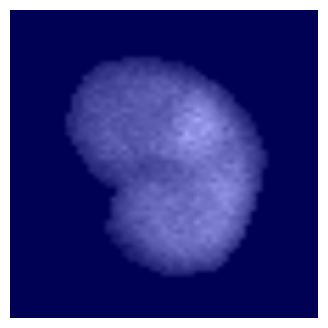

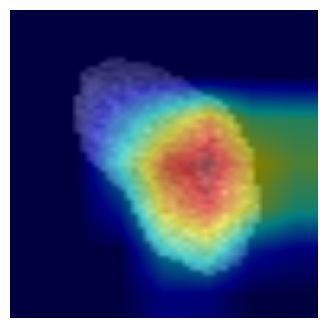

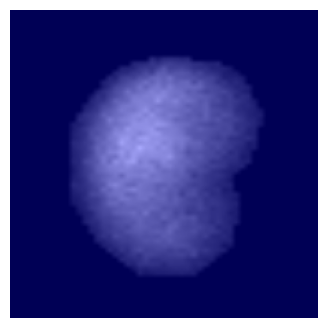

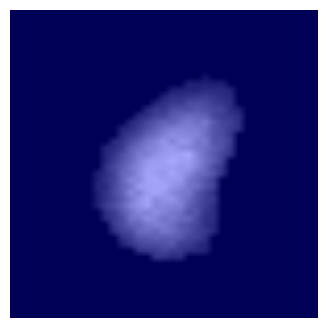

In [148]:
import matplotlib.pyplot as plt

for i in range(min(4, images.size(0))):
    img = images[i].cpu().numpy()[0]  # grayscale
    img = (img - img.min()) / (img.max() - img.min())

    cam_img = show_cam_on_image(
        np.stack([img]*3, axis=-1),
        grayscale_cams[i],
        use_rgb=True
    )

    plt.figure(figsize=(4,4))
    plt.imshow(cam_img)
    plt.axis("off")
    plt.show()


In [1]:
# FULL CELL — Generate model diagram (Predicted masks) + sanity checks (svgwrite-safe)

from pathlib import Path
import sys

# ----------------------------
# 0) Dependency sanity check
# ----------------------------
try:
    import svgwrite
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "svgwrite is not installed in this kernel.\n"
        "Run this in a NEW cell first:\n"
        "  import sys\n"
        "  !{sys.executable} -m pip install -q svgwrite\n"
        "Then restart kernel and run this cell again."
    )

from IPython.display import SVG, display


# ----------------------------
# 1) Drawing helpers (NO rgba)
# ----------------------------
def add_3d_block(dwg, x, y, w, h, color_front, depth=14, label="", label_color="white", font_size=14):
    # front face
    dwg.add(dwg.rect(
        insert=(x, y), size=(w, h), rx=6, ry=6,
        fill=color_front, stroke="black", stroke_width=1
    ))

    # right side face (use fill_opacity instead of rgba)
    dwg.add(dwg.polygon(
        points=[
            (x + w, y),
            (x + w + depth, y + depth),
            (x + w + depth, y + h + depth),
            (x + w, y + h),
        ],
        fill="#000000", fill_opacity=0.25,
        stroke="black", stroke_width=1
    ))

    # top face highlight
    dwg.add(dwg.polygon(
        points=[
            (x, y),
            (x + depth, y + depth),
            (x + w + depth, y + depth),
            (x + w, y),
        ],
        fill="#ffffff", fill_opacity=0.10,
        stroke="black", stroke_width=0.5
    ))

    # label (multi-line via tspans)
    if label:
        lines = label.split("\n")
        # baseline roughly centered
        start_y = y + h/2 - (len(lines)-1)*8
        t = dwg.text(
            "", insert=(x + w/2, start_y),
            text_anchor="middle",
            font_size=font_size, fill=label_color,
            font_family="Arial"
        )
        for i, ln in enumerate(lines):
            t.add(dwg.tspan(ln, x=[x + w/2], dy=[0 if i == 0 else 18]))
        dwg.add(t)


def add_arrow(dwg, x1, y1, x2, y2, color="#666", width=3):
    # one marker per drawing (safe re-use across svgwrite versions)
    marker = None
    get_by_id = getattr(dwg.defs, "get_element_by_id", None)
    if callable(get_by_id):
        try:
            marker = get_by_id("arrow")
        except Exception:
            marker = None

    if marker is None:
        for el in getattr(dwg.defs, "elements", []):
            try:
                if el.get_id() == "arrow":
                    marker = el
                    break
            except Exception:
                pass

    if marker is None:
        marker = dwg.marker(id="arrow", insert=(10, 5), size=(10, 10), orient="auto")
        marker.add(dwg.path(d="M 0 0 L 10 5 L 0 10 z", fill=color))
        dwg.defs.add(marker)

    line = dwg.line(start=(x1, y1), end=(x2, y2), stroke=color, stroke_width=width)
    line.set_markers((None, None, marker.get_funciri()))
    dwg.add(line)


def add_round_label(dwg, x, y, w, h, text, stroke="#b8f0b1", fill="none", font_size=16, text_fill="black"):
    dwg.add(dwg.rect(
        insert=(x, y), size=(w, h), rx=14, ry=14,
        fill=fill, stroke=stroke, stroke_width=4
    ))
    dwg.add(dwg.text(
        text, insert=(x + w/2, y + h/2 + 6),
        text_anchor="middle",
        font_size=font_size, fill=text_fill,
        font_family="Arial"
    ))


def add_right_panel_nn(dwg, x, y, w, h, out_labels, label_gap=10, label_w=170):
    # yellow panel
    dwg.add(dwg.rect(
        insert=(x, y), size=(w, h), rx=6, ry=6,
        fill="#fff59d", stroke="black", stroke_width=1.5
    ))

    # node positions
    left_nodes = [(x + 40, y + 40 + i*55) for i in range(5)]
    right_nodes = [(x + w - 55, y + 70 + i*55) for i in range(4)]

    # connections
    for lx, ly in left_nodes:
        for rx, ry in right_nodes:
            dwg.add(dwg.line(
                start=(lx, ly), end=(rx, ry),
                stroke="#1a237e", stroke_width=1, opacity=0.35
            ))

    # nodes
    for lx, ly in left_nodes:
        dwg.add(dwg.circle(center=(lx, ly), r=18, fill="#ff6f00", stroke="black", stroke_width=1))
    for rx, ry in right_nodes:
        dwg.add(dwg.circle(center=(rx, ry), r=18, fill="#039be5", stroke="black", stroke_width=1))

    # output labels boxes on the right
    lab_x = x + w + label_gap
    lab_y = y + 40
    for i, lab in enumerate(out_labels):
        dwg.add(dwg.rect(
            insert=(lab_x, lab_y + i*60), size=(label_w, 38),
            rx=6, ry=6, fill="#c8e6c9",
            stroke="black", stroke_width=1
        ))
        # multi-line label support
        lines = lab.split("\n")
        t = dwg.text(
            "", insert=(lab_x + label_w/2, lab_y + i*60 + 18),
            text_anchor="middle",
            font_size=12, fill="black",
            font_family="Arial"
        )
        for j, ln in enumerate(lines):
            t.add(dwg.tspan(ln, x=[lab_x + label_w/2], dy=[0 if j == 0 else 14]))
        dwg.add(t)




# ----------------------------
# 2) Build the diagram
# ----------------------------
# layout constants
x0, y0 = 330, 70
block_w, block_h, gap = 125, 250, 40
panel_w, panel_h = 250, 250
panel_gap = 30
label_w = 170
label_gap = 10
right_margin = 30

blocks = [
    ("4-Ch Inputs", "#1e88e5"),
    ("ConvNeXt\nBackbone", "#7e57c2"),
    ("View Fusion\n(P/LPO/RPO)", "#546e7a"),
    ("Heads\n(ConvNeXt + rules)", "#ef6c00"),
]

last_block_x = x0 + (len(blocks) - 1) * (block_w + gap)
panel_x = last_block_x + block_w + panel_gap

W = panel_x + panel_w + label_gap + label_w + right_margin
H = 420

# drawing
dwg = svgwrite.Drawing(size=(W, H), profile="full")  # profile full = fewer validation surprises

# background
dwg.add(dwg.rect(insert=(0, 0), size=(W, H), fill="white"))

# left labels
add_round_label(dwg, 55, 90, 210, 50, "Raw DMSA Image")
add_round_label(dwg, 55, 150, 210, 50, "Preprocess + RPO flip")
add_round_label(dwg, 55, 210, 210, 50, "Predicted Masks")

# center pipeline blocks
x = x0
for label, col in blocks:
    add_3d_block(dwg, x, y0, block_w, block_h, col, depth=14, label=label, font_size=14)
    x += block_w + gap

# arrows between blocks
x = x0
for _ in range(len(blocks) - 1):
    add_arrow(
        dwg,
        x + block_w + 10, y0 + block_h/2,
        x + block_w + gap - 10, y0 + block_h/2,
        color="#666", width=3
    )
    x += block_w + gap

# arrow from last block to right panel
add_arrow(
    dwg,
    last_block_x + block_w + 10, y0 + block_h/2,
    panel_x - 10, y0 + block_h/2,
    color="#666", width=3
)

# bottom legend boxes
bottom_y = 340
small = [
    ("Predicted Masks", "#b39ddb"),
    ("4-Ch Input", "#ef9a9a"),
    ("Geom Feats", "#b39ddb"),
    ("View Weights", "#ef9a9a"),
    ("Rule Heads", "#b39ddb"),
    ("ConvNeXt Heads", "#ef9a9a"),
]

bx = x0
small_w = 150
small_gap = 20
for txt, stroke in small:
    add_round_label(dwg, bx, bottom_y, small_w, 45, txt, stroke=stroke, text_fill="black", font_size=13)
    bx += small_w + small_gap

# right NN panel + outputs
add_right_panel_nn(
    dwg,
    x=panel_x, y=70, w=panel_w, h=panel_h,
    out_labels=[
        "Kidney Count\n(from masks)",
        "Anatomy\n(staged rules)",
        "Position\n(rule-based)",
        "Size + Uptake\n(ConvNeXt)",
    ],
    label_gap=label_gap,
    label_w=label_w,
)
# ----------------------------
# 3) Save + sanity checks
# ----------------------------
out_svg = Path("model_diagram_pred_masks.svg")
dwg.saveas(out_svg.as_posix())

# Basic file checks
assert out_svg.exists(), "SVG file was not created."
size_bytes = out_svg.stat().st_size
assert size_bytes > 5000, f"SVG looks too small ({size_bytes} bytes) — likely blank or failed draw."

# Content sanity checks (quick string checks)
txt = out_svg.read_text(encoding="utf-8", errors="ignore")
must_have = ["4-Ch Inputs", "ConvNeXt", "Predicted Masks", "Heads", "<svg", "</svg>"]
missing = [k for k in must_have if k not in txt]
assert not missing, f"SVG missing expected tokens: {missing}"

print("Diagram saved:", out_svg.resolve())
print("File size:", size_bytes, "bytes")

# Display in-notebook
display(SVG(filename=str(out_svg)))


Diagram saved: D:\model_diagram_pred_masks.svg
File size: 8946 bytes


In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# If test_labels/test_preds not already computed, compute them now
if "test_labels" not in globals() or "test_preds" not in globals():
    model.eval()
    test_labels, test_preds = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            probs = torch.sigmoid(model(images).squeeze())
            test_preds.extend(probs.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

# ROC + AUC
fpr, tpr, _ = roc_curve(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_preds)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.4f})")
plt.plot([0,1], [0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Scar")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("AUC:", auc)


NameError: name 'model' is not defined

In [1]:
plt.plot(train_aucs, label="train_auc")
plt.plot(val_aucs, label="val_auc")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.title("AUC vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'plt' is not defined

In [3]:
import json, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

NB_PATH = Path(r"C:\Users\User\Downloads\SCAR_UPDATED.ipynb")

nb = json.loads(NB_PATH.read_text(encoding="utf-8"))

lines = []
for cell in nb.get("cells", []):
    for out in cell.get("outputs", []):
        text = ""
        if "text" in out:
            t = out["text"]
            text = "".join(t) if isinstance(t, list) else str(t)
        elif isinstance(out.get("data"), dict) and "text/plain" in out["data"]:
            t = out["data"]["text/plain"]
            text = "".join(t) if isinstance(t, list) else str(t)
        if text:
            lines.extend(text.splitlines())

pat = re.compile(
    r"Epoch\s+\[(\d+)/(\\d+)\]\s+Train Loss:\s*([0-9.]+)\s+Train AUC:\s*([0-9.]+)\s+Val Loss:\s*([0-9.]+)\s+Val AUC:\s*([0-9.]+)"
)

rows = []
for line in lines:
    m = pat.search(line)
    if m:
        rows.append({
            "epoch": int(m.group(1)),
            "train_loss": float(m.group(3)),
            "train_auc": float(m.group(4)),
            "val_loss": float(m.group(5)),
            "val_auc": float(m.group(6)),
        })

df = pd.DataFrame(rows).sort_values("epoch")
if df.empty:
    print("No AUC logs found in notebook outputs (maybe outputs were cleared).")
else:
    df.to_csv(NB_PATH.with_suffix(".auc_log.csv"), index=False)
    print("Saved:", NB_PATH.with_suffix(".auc_log.csv"))

    plt.figure(figsize=(6,4))
    plt.plot(df["epoch"], df["train_auc"], label="train_auc")
    plt.plot(df["epoch"], df["val_auc"], label="val_auc")
    plt.xlabel("epoch")
    plt.ylabel("AUC")
    plt.title("AUC vs Epoch (from saved outputs)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


KeyError: 'epoch'

Saved: C:\Users\User\Downloads\SCAR_UPDATED.auc_log.csv


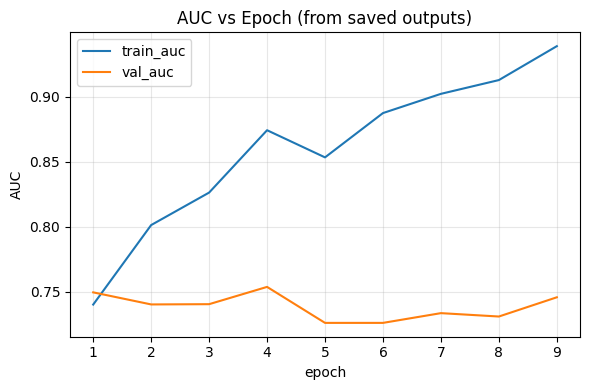

In [4]:
import json, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

NB_PATH = Path(r"C:\Users\User\Downloads\SCAR_UPDATED.ipynb")
nb = json.loads(NB_PATH.read_text(encoding="utf-8"))

lines = []
for cell in nb.get("cells", []):
    for out in cell.get("outputs", []):
        text = ""
        if "text" in out:
            t = out["text"]
            text = "".join(t) if isinstance(t, list) else str(t)
        elif isinstance(out.get("data"), dict) and "text/plain" in out["data"]:
            t = out["data"]["text/plain"]
            text = "".join(t) if isinstance(t, list) else str(t)
        if text:
            lines.extend(text.splitlines())

# More tolerant regex
pat = re.compile(
    r"Epoch\s*\[?(\d+)[/ ]+\d+\]?\s+.*?Train Loss:\s*([0-9.]+)\s+Train AUC:\s*([0-9.]+)\s+Val Loss:\s*([0-9.]+)\s+Val AUC:\s*([0-9.]+)",
    re.IGNORECASE
)

rows = []
for line in lines:
    m = pat.search(line)
    if m:
        rows.append({
            "epoch": int(m.group(1)),
            "train_loss": float(m.group(2)),
            "train_auc": float(m.group(3)),
            "val_loss": float(m.group(4)),
            "val_auc": float(m.group(5)),
        })

df = pd.DataFrame(rows)
if df.empty:
    print("No AUC logs found. Paste one sample epoch line and I’ll adjust the parser.")
else:
    df = df.sort_values("epoch")
    df.to_csv(NB_PATH.with_suffix(".auc_log.csv"), index=False)
    print("Saved:", NB_PATH.with_suffix(".auc_log.csv"))

    plt.figure(figsize=(6,4))
    plt.plot(df["epoch"], df["train_auc"], label="train_auc")
    plt.plot(df["epoch"], df["val_auc"], label="val_auc")
    plt.xlabel("epoch")
    plt.ylabel("AUC")
    plt.title("AUC vs Epoch (from saved outputs)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

